In [19]:
import os
import sys

from qiskit_aer.primitives import SamplerV2 as AerSampler

sys.path.append(os.path.abspath(".."))
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from qiskit_aer import AerSimulator

from open_qbench import ApplicationBenchmark
from open_qbench.analysis import FidelityAnalysis
from open_qbench.apps.circuits.qw import QW_Cycle, QW_Helpers
from open_qbench.core import BenchmarkInput
from open_qbench.metrics.fidelities import normalized_fidelity


# Display classical results
def plot_results_dict(results_dict, trials):
    positions = list(results_dict.keys())
    frequencies = list(results_dict.values())
    probabilities = [frequency / trials for frequency in frequencies]

    plt.figure(figsize=(10, 6))
    plt.scatter(positions, probabilities)
    plt.xlabel("Position")
    plt.ylabel("Probability")
    plt.title("Position distribution")
    plt.show()

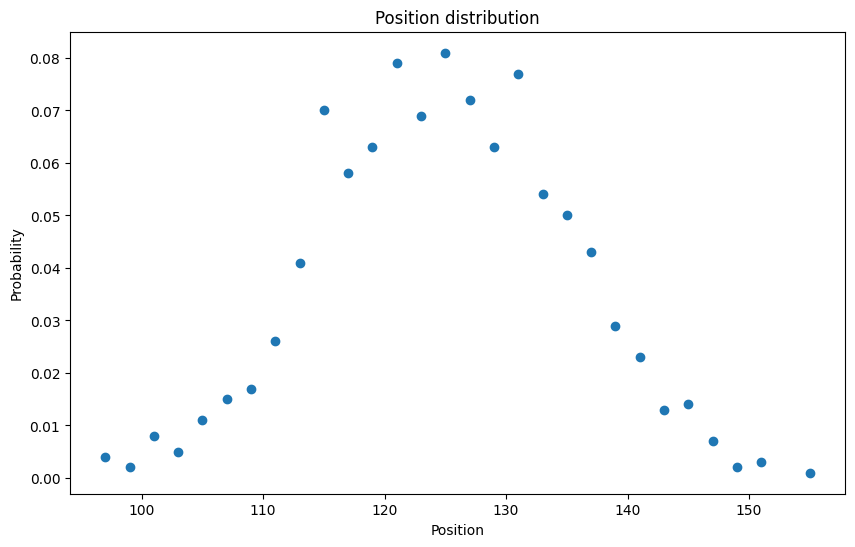

In [20]:
initial_pos = 125
steps = 100
trials = 1000
begin = 0
end = 255

result = Counter()
coin = np.random.default_rng()
result_update = result.update
for _ in range(trials):
    pos = initial_pos
    for _ in range(steps):
        move = coin.choice([-1, 1])
        pos += move
        if pos < begin:
            pos = end
        elif pos > end:
            pos = begin
    result_update([pos])

plot_results_dict(result, trials)

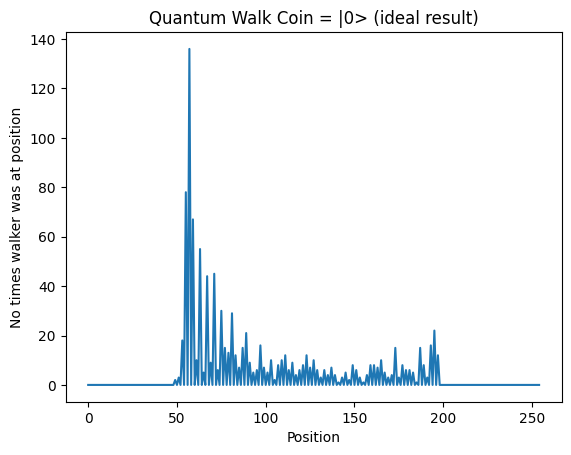

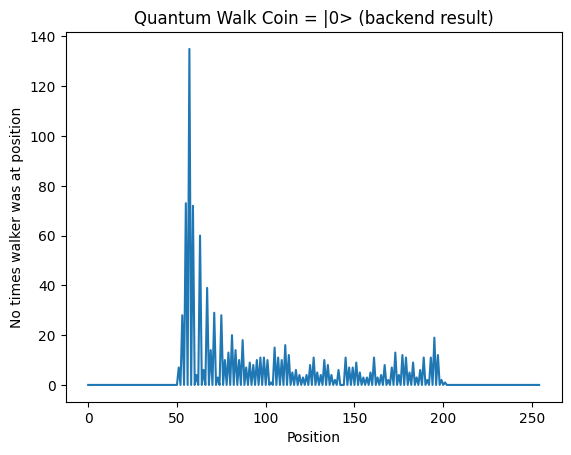

In [21]:
no_attempts = 1000
circuit_size = 255
qw_helpers = QW_Helpers()
qw_cycle = QW_Cycle()
no_qubits = len(bin(circuit_size)) - 1
ideal_sampler_v1 = AerSampler(default_shots=no_attempts)
backend_v1 = AerSimulator()
backend_sampler_v1 = AerSampler.from_backend(backend_v1, default_shots=no_attempts)

pos_0 = qw_helpers.to_ket(125, no_qubits - 1)
coin_v1 = qw_helpers.k_zero
no_steps_v1 = 100
psi_0_v1 = np.kron(coin_v1, pos_0)
circuit_v1 = qw_cycle.create_dtqw_circuit(no_qubits, no_steps_v1, psi_0_v1)

ab_v1 = ApplicationBenchmark(
    backend_sampler_v1,
    ideal_sampler_v1,
    BenchmarkInput(circuit_v1, backend_v1),
    analysis=FidelityAnalysis(normalized_fidelity),
    name="Quantum Walk Coin = |0>",
)
ab_v1.run()
ideal_result_v1 = ab_v1.result.to_dict()["execution_data"]["counts_ideal"]
backend_result_v1 = ab_v1.result.to_dict()["execution_data"]["counts_backend"]


qw_helpers.display_res_with_coin(
    ideal_result_v1, 0, circuit_size, "Quantum Walk Coin = |0> (ideal result)"
)
qw_helpers.display_res_with_coin(
    backend_result_v1, 0, circuit_size, "Quantum Walk Coin = |0> (backend result)"
)

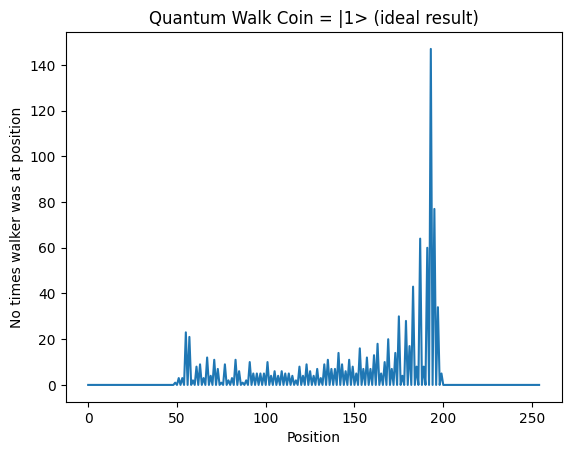

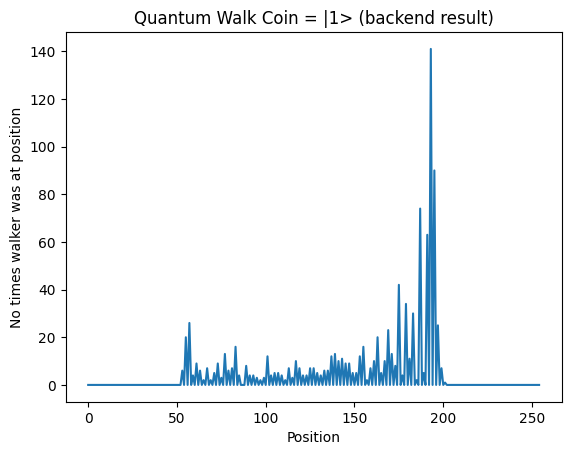

In [22]:
ideal_sampler_v2 = AerSampler(default_shots=no_attempts)
backend_v2 = AerSimulator()
backend_sampler_v2 = AerSampler.from_backend(backend_v2, default_shots=no_attempts)
coin_v2 = qw_helpers.k_one
no_steps_v2 = 100
psi_0_v2 = np.kron(coin_v2, pos_0)
circuit_v2 = qw_cycle.create_dtqw_circuit(no_qubits, no_steps_v2, psi_0_v2)
ab_v2 = ApplicationBenchmark(
    backend_sampler_v2,
    ideal_sampler_v2,
    BenchmarkInput(circuit_v2, backend_v2),
    analysis=FidelityAnalysis(normalized_fidelity),
    name="Quantum Walk Coin = |1>",
)
ab_v2.run()

ideal_result_v2 = ab_v2.result.to_dict()["execution_data"]["counts_ideal"]
backend_result_v2 = ab_v2.result.to_dict()["execution_data"]["counts_backend"]


qw_helpers.display_res_with_coin(
    ideal_result_v2, 0, circuit_size, "Quantum Walk Coin = |1> (ideal result)"
)
qw_helpers.display_res_with_coin(
    backend_result_v2, 0, circuit_size, "Quantum Walk Coin = |1> (backend result)"
)

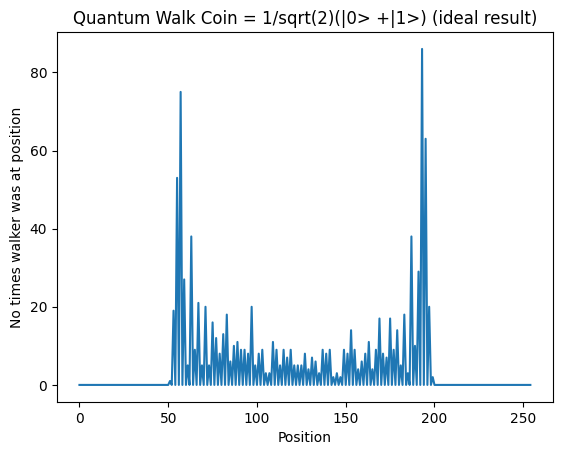

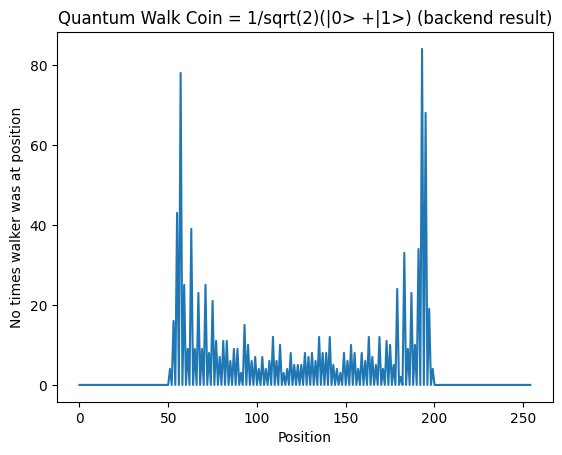

In [23]:
ideal_sampler_v3 = AerSampler(default_shots=no_attempts)
backend_v3 = AerSimulator()
backend_sampler_v3 = AerSampler.from_backend(backend_v3, default_shots=no_attempts)

coin_v3 = (1 / np.sqrt(2) * qw_helpers.k_zero) + (1j / np.sqrt(2)) * qw_helpers.k_one
no_steps_v3 = 100
psi_0_v3 = np.kron(coin_v3, pos_0)
circuit_v3 = qw_cycle.create_dtqw_circuit(no_qubits, no_steps_v3, psi_0_v3)

ab_v3 = ApplicationBenchmark(
    backend_sampler_v3,
    ideal_sampler_v3,
    BenchmarkInput(circuit_v3, backend_v3),
    analysis=FidelityAnalysis(normalized_fidelity),
    name="Quantum Walk Coin = 1/sqrt(2)(|0> +|1>)",
)
ab_v3.run()

ideal_result_v3 = ab_v3.result.to_dict()["execution_data"]["counts_ideal"]
backend_result_v3 = ab_v3.result.to_dict()["execution_data"]["counts_backend"]


qw_helpers.display_res_with_coin(
    ideal_result_v3,
    0,
    circuit_size,
    "Quantum Walk Coin = 1/sqrt(2)(|0> +|1>) (ideal result)",
)
qw_helpers.display_res_with_coin(
    backend_result_v3,
    0,
    circuit_size,
    "Quantum Walk Coin = 1/sqrt(2)(|0> +|1>) (backend result)",
)